In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import lightkurve as lk
from astropy.timeseries import BoxLeastSquares

/Users/suddin/miniconda3/lib/python3.13/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


Searching Lightkurve archive for TIC 150428135...
SearchResult containing 10 data products.

 #     mission     year       author      exptime target_name distance
                                             s                 arcsec 
--- -------------- ---- ----------------- ------- ----------- --------
  0 TESS Sector 01 2018              SPOC     120   150428135      0.0
  1 TESS Sector 01 2018         TESS-SPOC    1800   150428135      0.0
  2 TESS Sector 01 2018               QLP    1800   150428135      0.0
  3 TESS Sector 01 2018 GSFC-ELEANOR-LITE    1800   150428135      0.0
  4 TESS Sector 01 2018               T16    1800   150428135      0.0
  5 TESS Sector 01 2018              TARS    1800   150428135      0.0
  6 TESS Sector 01 2018             TASOC     120   150428135      0.0
  7 TESS Sector 01 2018             TASOC    1800   150428135      0.0
  8 TESS Sector 01 2018             TASOC    1800   150428135      0.0
  9 TESS Sector 01 2018              TGLC    1800   150

/Users/suddin/miniconda3/lib/python3.13/site-packages/lightkurve/search.py:421: LightkurveWarning: Warning: 10 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


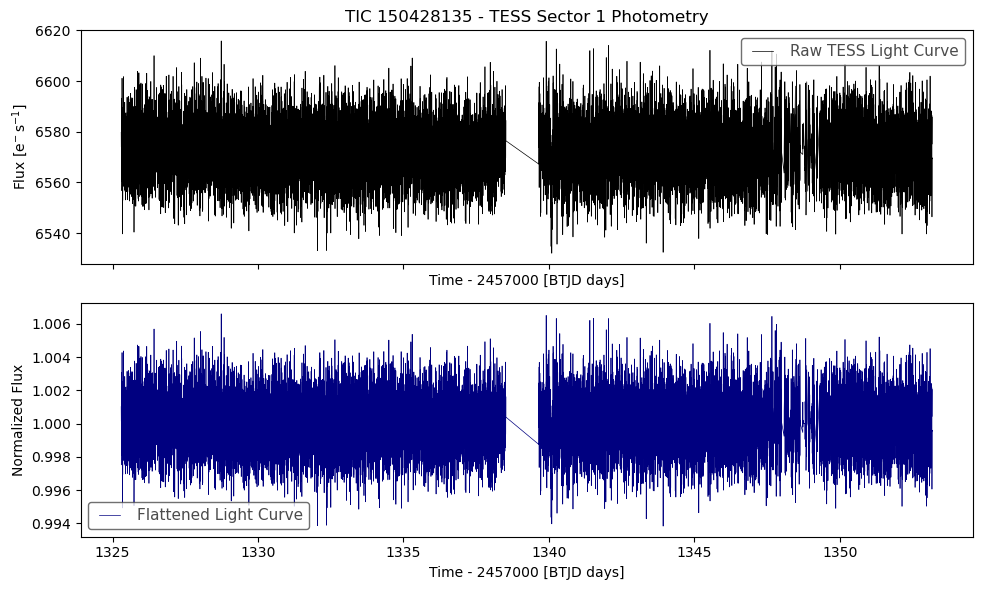

In [3]:
# -------------------------------------------------------------
# 1. Search and Download TESS Target Pixel / Lightcurve Data
# -------------------------------------------------------------
# Target: TOI-700 (TIC 150428135), host to multi-planet system
tic_id = "TIC 150428135"

print(f"Searching Lightkurve archive for {tic_id}...")
search_result = lk.search_lightcurve(tic_id, mission="TESS", sector=1)
print(search_result)

# Download light curve file
lc = search_result.download().remove_nans()

# -------------------------------------------------------------
# 2. Detrending and Systematics Cleaning
# -------------------------------------------------------------
# Remove long-term stellar variability using Savitzky-Golay filter
flat_lc = lc.flatten(window_length=1001)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
lc.plot(ax=ax1, color='k', label='Raw TESS Light Curve')
flat_lc.plot(ax=ax2, color='navy', label='Flattened Light Curve')
ax1.set_title(f"{tic_id} - TESS Sector 1 Photometry")
plt.tight_layout()
plt.show()


--- Best Fit BLS Parameters ---
Detected Period  : 14.8158 d
Transit Epoch T0 : 1340.0855 BTJD
Transit Duration : 1.20 h


<Figure size 800x400 with 0 Axes>

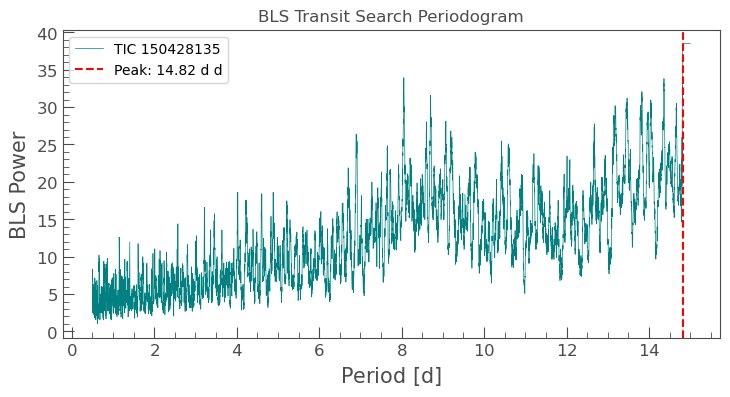

In [4]:
# -------------------------------------------------------------
# 3. Box-Least-Squares (BLS) Periodogram Search
# -------------------------------------------------------------
# Define period grid search limits (in days)
period_grid = np.linspace(0.5, 15.0, 10000)

bls = flat_lc.to_periodogram(
    method="bls", 
    period=period_grid, 
    duration=np.linspace(0.05, 0.25, 10)
)

best_period = bls.period_at_max_power
best_t0 = bls.transit_time_at_max_power
best_duration = bls.duration_at_max_power

print(f"\n--- Best Fit BLS Parameters ---")
print(f"Detected Period  : {best_period:.4f}")
print(f"Transit Epoch T0 : {best_t0.value:.4f} BTJD")
print(f"Transit Duration : {best_duration.to('hour'):.2f}")

# Plot BLS Periodogram
plt.figure(figsize=(8, 4))
bls.plot(color='teal')
plt.axvline(best_period.value, color='red', linestyle='--', label=f'Peak: {best_period:.2f} d')
plt.title("BLS Transit Search Periodogram")
plt.legend()
plt.show()

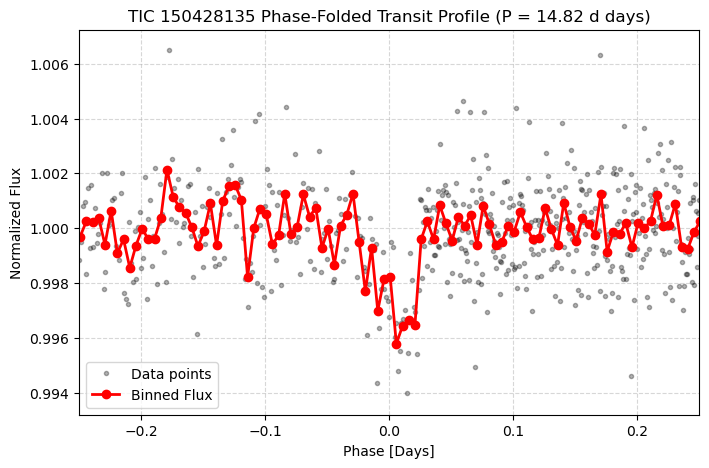

Estimated Transit Depth (delta): 0.422%
Derived Radius Ratio (Rp / R*) : 0.0650


In [5]:

# -------------------------------------------------------------
# 4. Phase Folding and Simple Transit Depth Estimation
# -------------------------------------------------------------
folded_lc = flat_lc.fold(period=best_period, epoch_time=best_t0)

plt.figure(figsize=(8, 5))
plt.plot(folded_lc.time.value, folded_lc.flux.value, 'k.', alpha=0.3, label='Data points')

# Bin light curve for clearer visual inspection
binned_lc = folded_lc.bin(time_bin_size=0.005)
plt.plot(binned_lc.time.value, binned_lc.flux.value, 'r-o', lw=2, label='Binned Flux')

plt.xlim(-0.25, 0.25)
plt.xlabel("Phase [Days]")
plt.ylabel("Normalized Flux")
plt.title(f"{tic_id} Phase-Folded Transit Profile (P = {best_period:.2f} days)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Estimate Planet Radius Ratio
min_flux = np.min(binned_lc.flux.value)
estimated_depth = 1.0 - min_flux
radius_ratio = np.sqrt(estimated_depth)

print(f"Estimated Transit Depth (delta): {estimated_depth*100:.3f}%")
print(f"Derived Radius Ratio (Rp / R*) : {radius_ratio:.4f}")